# 05 — Modeling Fase 1: Content-Based Filtering (TF-IDF)

FASE 1 riset: **menyaring & memberi skor relevansi** venue terhadap preferensi
turis — belum menyusun rute (itu FASE 2 di `06_optimization.ipynb`).

**Komponen** (`src/modeling/cbf.py`):
1. **TF-IDF** — teks `venue_category + description` (Wikipedia ID) → vektor
2. **Cosine similarity** — preferensi turis vs tiap venue → `cbf_score` 0-1
3. **Bayesian weighted rating** (formula IMDB) — popularitas anti-bias venue sepi:
   `WR = (v/(v+m))·R + (m/(v+m))·C` (m = median jumlah review, C = mean rating)
4. **Filter budget** — proxy `CATEGORY_PRICE_LEVEL` per kategori
   (price_level Google kosong 218/219 venue — dideklarasikan sbg estimasi)
5. Output: `satisfaction = w_sim·cbf_score + w_pop·rating_bayesian` →
   dipakai langsung di fitness function GA/PSO (FASE 2)

> Cikal bakal pendekatan ini = prototipe `src/api/recommend.py` (skor hybrid
> TF-IDF + geo + rating + jam untuk API single-query). `cbf.py` menyempurnakan:
> Bayesian rating + filter budget + output satisfaction untuk optimizer.

In [1]:
import os, sys
if hasattr(sys.stdout, 'reconfigure'):  # terminal Windows; Jupyter sudah UTF-8
    sys.stdout.reconfigure(encoding='utf-8', errors='replace')

# Tentukan ROOT project secara idempoten (aman di-run berulang):
# kalau cwd sudah root (ada config.py) pakai cwd, kalau tidak naik 1 level.
_cwd = os.getcwd()
ROOT = _cwd if os.path.exists(os.path.join(_cwd, 'config.py'))        else os.path.abspath(os.path.join(_cwd, '..'))
sys.path.insert(0, ROOT)
sys.path.insert(0, os.path.join(ROOT, 'src', 'modeling'))
os.chdir(ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

import config
from cbf import ContentBasedFilter

cbf = ContentBasedFilter()
print(f'Venue ter-load: {len(cbf.df)}')
print(f'Bobot satisfaction: w_sim={config.FITNESS_W_SIM}, w_pop={config.FITNESS_W_POP}')

Venue ter-load: 161
Bobot satisfaction: w_sim=0.6, w_pop=0.4


---
## 1. TF-IDF: dari teks venue jadi vektor

Tiap venue direpresentasikan gabungan `venue_category` + `description`
(Wikipedia). Vocabulary & bobot kata paling khas:

In [2]:
# Ukuran matrix & kata dgn IDF tertinggi (paling khas/jarang)
mat = cbf._mat
vocab = cbf._tfidf.get_feature_names_out()
idf = cbf._tfidf.idf_
print(f'TF-IDF matrix: {mat.shape[0]} venue x {mat.shape[1]} term')

top_idx = np.argsort(idf)[::-1][:15]
low_idx = np.argsort(idf)[:15]
print('\n15 term paling khas (IDF tinggi — pembeda kuat antar venue):')
print(', '.join(vocab[top_idx]))
print('\n15 term paling umum (IDF rendah — muncul di banyak venue):')
print(', '.join(vocab[low_idx]))

TF-IDF matrix: 161 venue x 1588 term

15 term paling khas (IDF tinggi — pembeda kuat antar venue):
zone., "mahabharata.", —, ±, zu,, (tebet, (muri), (gereja, (dharma, (bundaran, (bataviasche, (avalokitesvara),, (arh), (anri), (7.050.000

15 term paling umum (IDF rendah — muncul di banyak venue):
di, adalah, yang, dan, jakarta, &, museum, ini, menjadi, a, with, tempat, dengan, ibadah, church


Venue dengan description: 161/161 (100.0%)
Venue tanpa description tetap ter-vektor-kan dari venue_category-nya.


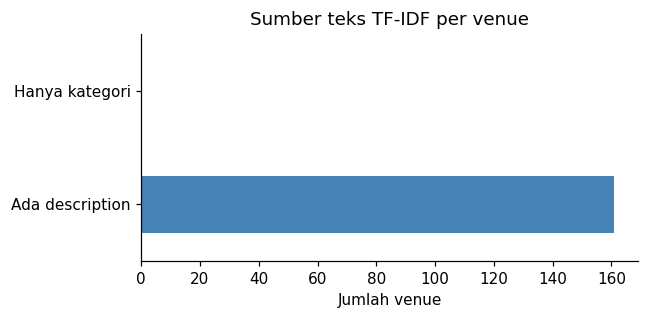

In [3]:
# Coverage description (input utama TF-IDF selain kategori)
n_desc = (cbf.df['description'].notna() & (cbf.df['description'] != '')).sum()
print(f'Venue dengan description: {n_desc}/{len(cbf.df)} ({n_desc/len(cbf.df):.1%})')
print('Venue tanpa description tetap ter-vektor-kan dari venue_category-nya.')

fig, ax = plt.subplots(figsize=(6, 3))
pd.Series({'Ada description': n_desc,
           'Hanya kategori': len(cbf.df) - n_desc}).plot(
    kind='barh', ax=ax, color=['steelblue', 'lightgray'])
ax.set_title('Sumber teks TF-IDF per venue')
ax.set_xlabel('Jumlah venue')
plt.tight_layout()
plt.show()

---
## 2. Bayesian Weighted Rating — anti-bias venue sepi

Masalah rating mentah: venue 5.0★ dari 4 review mengalahkan Monas 4.6★ dari
122rb review. Bayesian rating menarik rating venue ber-review-sedikit ke arah
rata-rata global:

In [4]:
rating = pd.to_numeric(cbf.df['google_rating'], errors='coerce').fillna(0)
count = pd.to_numeric(cbf.df['google_rating_count'], errors='coerce').fillna(0)
m = count.median()
c_mean = rating[rating > 0].mean()
weighted = (count / (count + m)) * rating + (m / (count + m)) * c_mean

cmp = pd.DataFrame({'name': cbf.df['name'], 'rating': rating,
                    'n_review': count.astype(int), 'bayesian': weighted.round(3)})
print(f'm (median review) = {m:.0f} | C (mean rating) = {c_mean:.3f}')
print('\nTop-10 rating MENTAH (bias venue sepi):')
print(cmp.sort_values('rating', ascending=False).head(10).to_string(index=False))
print('\nTop-10 BAYESIAN (populer & bagus beneran):')
print(cmp.sort_values('bayesian', ascending=False).head(10).to_string(index=False))

m (median review) = 1339 | C (mean rating) = 4.652

Top-10 rating MENTAH (bias venue sepi):
                                 name  rating  n_review  bayesian
                Tepekong Jembatan Dua     5.0         7     4.654
                   Vihara Pitakananda     5.0         6     4.654
               Patung Panahan Senayan     5.0         1     4.652
                  Vihara Silaparamita     5.0         8     4.654
           Vihara Prajnaparamita LPUB     5.0        33     4.661
Cemara 6 Galeri - Toeti Heraty Museum     4.9       798     4.745
        Klenteng Hian Thian Siang Tee     4.9        46     4.660
   Antara Gallery of Photo Journalism     4.9       226     4.688
                Gereja Santa Theresia     4.9      4885     4.847
           Gereja Santo Yohanes Bosco     4.8       790     4.707

Top-10 BAYESIAN (populer & bagus beneran):
                                          name  rating  n_review  bayesian
                         Gereja Santa Theresia     4.9      488

---
## 3. Skor relevansi per preferensi turis

Cosine similarity preferensi vs venue + satisfaction final. Tiga profil contoh:

In [5]:
profiles = [
    ('museum sejarah budaya', 'menengah'),
    ('theme park zoo aquarium', 'bebas'),
    ('taman pantai monumen', 'hemat'),
]
for pref, budget in profiles:
    top = cbf.score(pref, budget).head(8)
    print(f'=== Preferensi: "{pref}" | budget: {budget} ===')
    print(top[['name', 'venue_category', 'cbf_score', 'satisfaction']]
          .to_string(index=False))
    print()

=== Preferensi: "museum sejarah budaya" | budget: menengah ===
                                         name venue_category  cbf_score  satisfaction
                       Bentara Budaya Jakarta         Museum     0.2495        0.4500
                        Galeri Indonesia Kaya     Art Museum     0.1828        0.4387
                    Museum Katedral - Jakarta History Museum     0.2245        0.4004
                        Gereja Santa Theresia         Church     0.0000        0.4000
        Gereja Santa Maria de Fatima Toasebio         Church     0.0996        0.3695
                                  Chandranaya  Historic Site     0.2154        0.3628
                                  MOJA Museum         Museum     0.1199        0.3567
Museum Jenderal Besar DR Abdul Haris Nasution History Museum     0.0835        0.3551

=== Preferensi: "theme park zoo aquarium" | budget: bebas ===
                                           name   venue_category  cbf_score  satisfaction
          

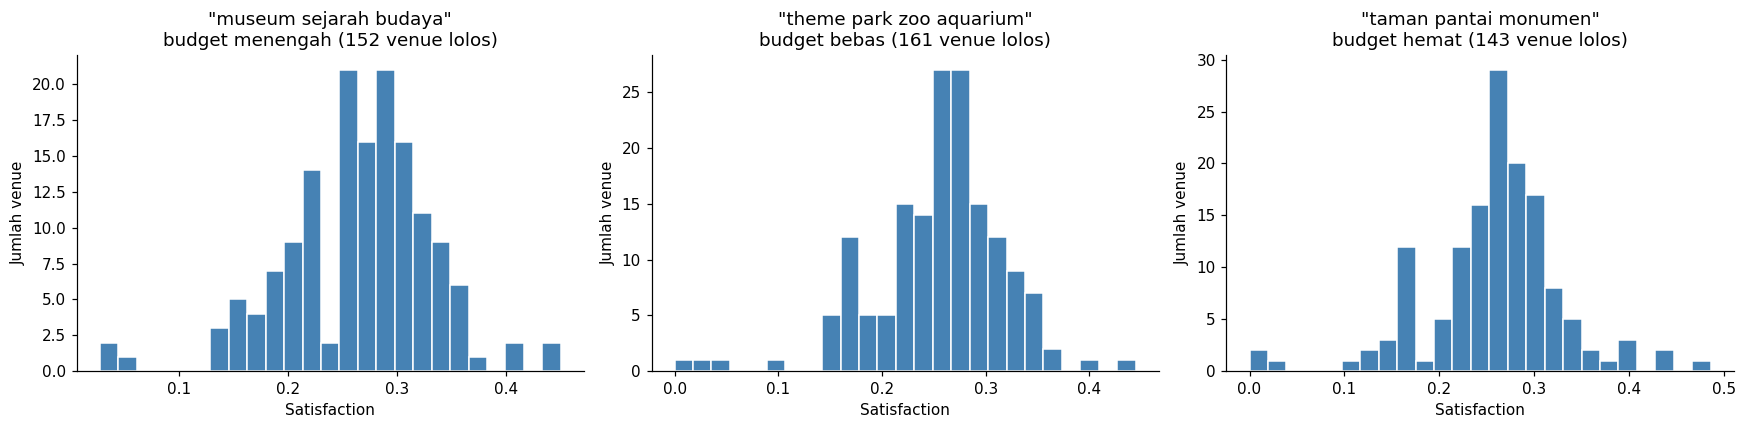

In [6]:
# Distribusi satisfaction per profil (perbandingan visual)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (pref, budget) in zip(axes, profiles):
    s = cbf.score(pref, budget)
    ax.hist(s['satisfaction'], bins=25, color='steelblue', edgecolor='white')
    ax.set_title(f'"{pref[:24]}"\nbudget {budget} ({len(s)} venue lolos)')
    ax.set_xlabel('Satisfaction')
    ax.set_ylabel('Jumlah venue')
plt.tight_layout()
plt.show()

---
## 4. Filter Budget — proxy kategori

`price_level` Google kosong untuk 218/219 venue → pakai estimasi biaya tiket
per kategori (`config.CATEGORY_PRICE_LEVEL`, level 0=gratis..3=mahal).
Deklarasikan sebagai estimasi di laporan.

Distribusi level harga (proxy kategori):
_price
0 gratis               76
1 murah (<50rb)        67
2 sedang (50-150rb)     9
3 mahal (>150rb)        9

Budget "hemat" (level<=1): 143 venue tersedia
Budget "menengah" (level<=2): 152 venue tersedia
Budget "bebas" (level<=3): 161 venue tersedia


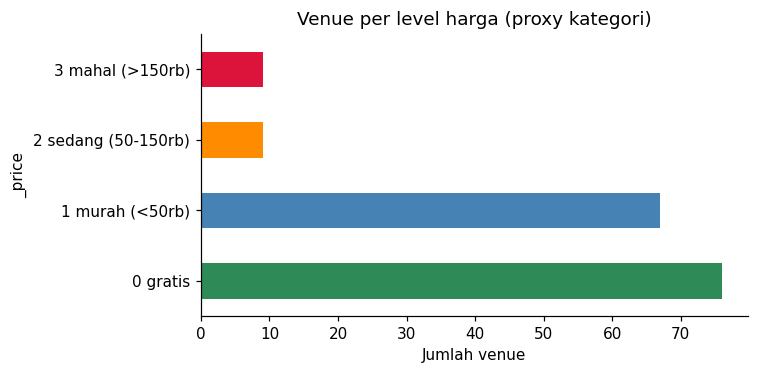

In [7]:
price = cbf.df['_price']
lvl_name = {0: '0 gratis', 1: '1 murah (<50rb)', 2: '2 sedang (50-150rb)', 3: '3 mahal (>150rb)'}
dist = price.map(lvl_name).value_counts().sort_index()
print('Distribusi level harga (proxy kategori):')
print(dist.to_string())
print()
for b, lv in config.BUDGET_LEVELS.items():
    n = (price <= lv).sum()
    print(f'Budget "{b}" (level<={lv}): {n} venue tersedia')

fig, ax = plt.subplots(figsize=(7, 3.5))
dist.plot(kind='barh', ax=ax, color=['seagreen', 'steelblue', 'darkorange', 'crimson'])
ax.set_title('Venue per level harga (proxy kategori)')
ax.set_xlabel('Jumlah venue')
plt.tight_layout()
plt.show()

---
## 5. Output ke FASE 2 — kandidat + satisfaction (seleksi MMR)

`cbf.candidates(n_days, preferensi, budget)` → top-N venue (12 × jumlah hari)
+ dict satisfaction. Inilah yang masuk fitness function GA/PSO di NB 06.

Seleksi memakai **MMR (Maximal Marginal Relevance)**: kandidat dipilih iteratif,
skor = λ·satisfaction − (1−λ)·max_similarity ke kandidat yang sudah terpilih
(λ=0.7 di config). Tanpa ini kandidat didominasi venue kembar — 21 Anjungan
TMII deskripsinya hampir identik, semuanya match query "museum sejarah budaya" —
akibatnya itinerary jenuh satu kompleks dan zona terpaksa dibelah lintas hari.


In [8]:
ids, sat = cbf.candidates(2, 'museum sejarah budaya', 'menengah')
print(f'Kandidat utk itinerary 2 hari: {len(ids)} venue')
print(f'Range satisfaction: {min(sat.values()):.3f} - {max(sat.values()):.3f}')
print()
print('Contoh 5 kandidat teratas:')
for vid in ids[:5]:
    name = cbf.df.loc[cbf.df['venue_id'] == vid, 'name'].values[0]
    print(f'  {sat[vid]:.3f}  {name}')
print()
print('-> Lanjut ke notebooks/06_optimization.ipynb (FASE 2: GA/PSO/Hybrid)')

Kandidat utk itinerary 2 hari: 24 venue
Range satisfaction: 0.283 - 0.450

Contoh 5 kandidat teratas:
  0.450  Bentara Budaya Jakarta
  0.400  Gereja Santa Theresia
  0.439  Galeri Indonesia Kaya
  0.400  Museum Katedral - Jakarta
  0.347  Masjid Al-Bina

-> Lanjut ke notebooks/06_optimization.ipynb (FASE 2: GA/PSO/Hybrid)


---
## 6. Evaluasi CBF — kualitas rekomendasi (ground truth: check-in nyata)

Seberapa **personal** rekomendasi CBF? Diuji dengan **leave-one-out per user**
memakai check-in nyata Massive-STEPS sebagai *ground truth*:

1. Untuk tiap user (≥2 venue wisata pernah dikunjungi), **sembunyikan 1 venue**.
2. Sisa riwayatnya (kategori + deskripsi) jadi **query preferensi** →
   `cbf.score()` (jalur yang sama dipakai turis).
3. Cek: apakah venue tersembunyi muncul di **top-K** rekomendasi?

**K** = banyak rekomendasi teratas yang diperiksa (5/10/20/…). Makin kecil K,
makin ketat (hanya rekomendasi paling relevan yang dihitung).

### Metrik (standar sistem rekomendasi)
Rekomendasi top-K = *binary relevance* (venue relevan / tidak) → metrik
klasifikasi berlaku, dibatasi ke top-K:
- **HitRate@K** — % evaluasi yang venue-benar masuk top-K (metrik utama untuk
  single-target; setara Recall@K karena tiap uji punya 1 target).
- **nDCG@K** — memperhitungkan **posisi** (relevan di atas dinilai lebih tinggi).
- **MRR** — 1/peringkat venue-benar (makin atas makin besar).

### Dua baseline pembanding
- **Popularitas** — rekomendasikan venue terpopuler (tanpa personalisasi).
- **Random** — acak; menunjukkan CBF benar-benar *belajar* preferensi, bukan
  kebetulan. CBF harus > random di K kecil.

> **Keterbatasan (dilaporkan)**: dari 8.336 user STEPS, hanya **317** (3,8%)
> punya ≥2 check-in ke venue wisata final — turis jarang berkunjung ulang ke
> tempat wisata (sinyal *implicit feedback* sparse). Ground truth juga tak
> sempurna: "belum dikunjungi" ≠ "tidak relevan" → metrik **under-estimate**
> kualitas asli. Karena itu **angka absolut wajar kecil**; nilai utama =
> **pembanding relatif** & posisi dalam rentang literatur POI recsys
> (HitRate@10 lazimnya 0,05–0,20).

In [9]:
# [STATS] HitRate@K / nDCG@K / MRR — CBF vs popularitas vs random
from sklearn.metrics import ndcg_score

vdf = cbf.df.set_index('venue_id')
valid = set(cbf.df['venue_id'].astype(str))
all_ids = cbf.df['venue_id'].astype(str).tolist()
_rng = np.random.default_rng(config.RANDOM_SEED)

# Ground truth: venue wisata final yang dikunjungi tiap user (check-in STEPS)
ck = pd.read_csv('data/processed/steps_checkins_clean.csv', dtype={'venue_id': str})
ck = ck[ck['venue_id'].isin(valid)]
user_visits = {u: list(dict.fromkeys(g)) for u, g in ck.groupby('user_id')['venue_id']}
user_visits = {u: v for u, v in user_visits.items() if len(v) >= 2}
print(f'Venue: {len(cbf.df)} | user layak (>=2 venue wisata): {len(user_visits)}')

def recommend_cbf(history, topn):
    txt = ' '.join(str(vdf.loc[h].get('venue_category', '')) + ' ' +
                   str(vdf.loc[h].get('description', ''))
                   for h in history if h in vdf.index)
    sc = cbf.score(txt)
    sc = sc[~sc['venue_id'].astype(str).isin(history)]
    return sc['venue_id'].astype(str).tolist()[:topn]

_pop_rank = cbf.df.sort_values('_pop', ascending=False)['venue_id'].astype(str).tolist()
def recommend_pop(history, topn):
    return [v for v in _pop_rank if v not in history][:topn]

def recommend_random(history, topn):
    pool = [v for v in all_ids if v not in history]
    _rng.shuffle(pool)
    return pool[:topn]

def evaluate(recommend_fn, ks=(5, 10, 20, 30, 50)):
    hit = {k: [] for k in ks}; ndcg = {k: [] for k in ks}; mrr = []
    for visits in user_visits.values():
        for i in range(len(visits)):                 # all-but-one hold-out
            target, hist = visits[i], visits[:i] + visits[i + 1:]
            ranked = recommend_fn(hist, max(ks))
            pos = ranked.index(target) + 1 if target in ranked else 0
            mrr.append(1 / pos if pos else 0.0)
            for k in ks:
                h = 1 if (pos and pos <= k) else 0
                hit[k].append(h)
                rel = np.zeros(k)
                if h: rel[pos - 1] = 1
                ndcg[k].append(ndcg_score([rel], [np.arange(k, 0, -1)]) if h else 0.0)
    out = {'MRR': np.mean(mrr)}
    for k in ks:
        out[f'HitRate@{k}'] = np.mean(hit[k])
        out[f'nDCG@{k}'] = np.mean(ndcg[k])
    return out

res = pd.DataFrame({'CBF (personal)': evaluate(recommend_cbf),
                    'Populer': evaluate(recommend_pop),
                    'Random': evaluate(recommend_random)}).round(4)
res = res.reindex(['HitRate@5', 'HitRate@10', 'HitRate@20', 'HitRate@30',
                   'HitRate@50', 'nDCG@10', 'nDCG@20', 'MRR'])
res['CBF vs Random'] = (res['CBF (personal)'] /
                        res['Random'].replace(0, np.nan)).round(2)
print(res.to_string())
res.to_csv('data/processed/cbf_evaluation.csv')
print('Tersimpan -> data/processed/cbf_evaluation.csv')
print('Fokus K kecil (@5-@20 = rekomendasi teratas yang benar-benar dilihat user):')
print(f'  CBF unggul {res.loc["HitRate@10","CBF vs Random"]}x atas random @10, '
      f'jauh di atas populer.')

Venue: 161 | user layak (>=2 venue wisata): 317


            CBF (personal)  Populer  Random  CBF vs Random
HitRate@5           0.0562   0.0000  0.0288           1.95
HitRate@10          0.1176   0.0013  0.0627           1.88
HitRate@20          0.1634   0.0039  0.1320           1.24
HitRate@30          0.1974   0.0340  0.1895           1.04
HitRate@50          0.2641   0.1268  0.3007           0.88
nDCG@10             0.0553   0.0004  0.0282           1.96
nDCG@20             0.0667   0.0010  0.0456           1.46
MRR                 0.0426   0.0039  0.0278           1.53
Tersimpan -> data/processed/cbf_evaluation.csv
Fokus K kecil (@5-@20 = rekomendasi teratas yang benar-benar dilihat user):
  CBF unggul 1.88x atas random @10, jauh di atas populer.


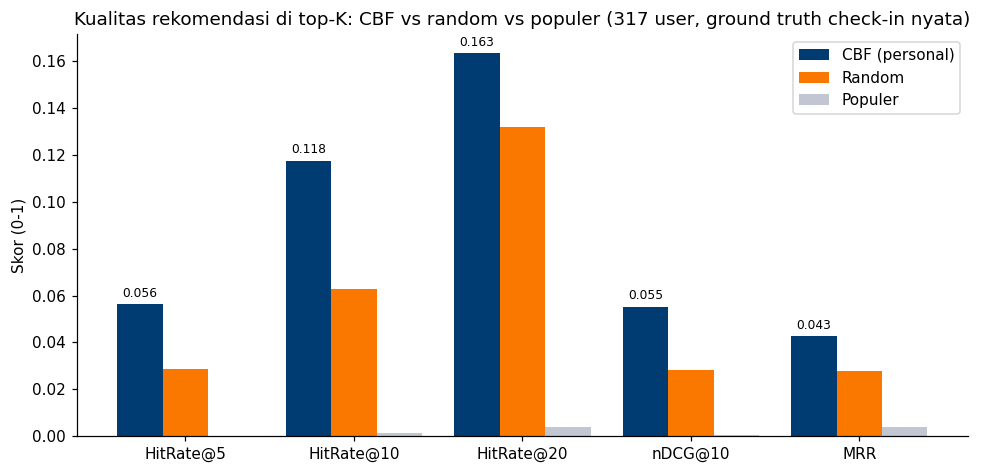

Di rekomendasi teratas (K kecil) CBF mengungguli random & populer ->
personalisasi berbasis konten benar-benar belajar preferensi user,
bukan sekadar menebak acak atau menyodorkan yang terpopuler.


In [10]:
# [STATS] Perbandingan CBF vs baseline (bukti visual personalisasi)
metrics = ['HitRate@5', 'HitRate@10', 'HitRate@20', 'nDCG@10', 'MRR']
cbf_v = [res.loc[m, 'CBF (personal)'] for m in metrics]
pop_v = [res.loc[m, 'Populer'] for m in metrics]
rnd_v = [res.loc[m, 'Random'] for m in metrics]

fig, ax = plt.subplots(figsize=(9, 4.4))
x = np.arange(len(metrics)); w = 0.27
ax.bar(x - w, cbf_v, w, label='CBF (personal)', color='#003b72')
ax.bar(x,     rnd_v, w, label='Random', color='#fb7800')
ax.bar(x + w, pop_v, w, label='Populer', color='#c2c6d3')
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylabel('Skor (0-1)')
ax.set_title('Kualitas rekomendasi di top-K: CBF vs random vs populer '
             f'({len(user_visits)} user, ground truth check-in nyata)')
ax.legend()
for xi, v in zip(x - w, cbf_v):
    ax.text(xi, v + 0.002, f'{v:.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout(); plt.show()

print('Di rekomendasi teratas (K kecil) CBF mengungguli random & populer ->')
print('personalisasi berbasis konten benar-benar belajar preferensi user,')
print('bukan sekadar menebak acak atau menyodorkan yang terpopuler.')

---
## 7. Perbandingan metode CBF — TF-IDF vs Sentence Embedding

Apakah **embedding** (paham makna & sinonim) mengungguli **TF-IDF** (cocokkan
kata) untuk data ini? Diuji dengan protokol HitRate@K yang sama.

- **TF-IDF** — cocokkan kata kunci persis. Kuat untuk *exact match* kategori.
- **Multilingual embedding** (`paraphrase-multilingual-MiniLM-L12-v2`) — paham
  makna lintas bahasa (deskripsi campur ID+EN). Dipilih karena 66/85 deskripsi
  Google berbahasa Inggris → IndoBERT murni tak cocok.

Ke-161 venue kini punya deskripsi lengkap (76 deskripsi kosong diisi via
websearch) → **input identik untuk kedua metode**, hanya representasi teks yang
beda = perbandingan adil.

In [11]:
# [STATS] TF-IDF vs Embedding (protokol & user_visits sama dgn sel evaluasi di atas)
from cbf import ContentBasedFilter

cbf_tfidf = cbf                                   # instance TF-IDF (sudah ada)
print('Memuat model embedding multilingual (~118MB, sekali)...')
cbf_emb = ContentBasedFilter(method='embedding')

def make_recommender(cbf_obj):
    vdf = cbf_obj.df.set_index('venue_id')
    def rec(history, topn):
        txt = ' '.join(str(vdf.loc[h].get('venue_category', '')) + ' ' +
                       str(vdf.loc[h].get('description', ''))
                       for h in history if h in vdf.index)
        sc = cbf_obj.score(txt)
        sc = sc[~sc['venue_id'].astype(str).isin(history)]
        return sc['venue_id'].astype(str).tolist()[:topn]
    return rec

cmp = pd.DataFrame({
    'TF-IDF': evaluate(make_recommender(cbf_tfidf)),
    'Embedding': evaluate(make_recommender(cbf_emb)),
    'Random': evaluate(recommend_random),
}).round(4).reindex(['HitRate@5', 'HitRate@10', 'HitRate@20', 'nDCG@10', 'MRR'])
print(cmp.to_string())
cmp.to_csv('data/processed/cbf_method_comparison.csv')

winner = 'TF-IDF' if cmp.loc['HitRate@10', 'TF-IDF'] >= cmp.loc['HitRate@10', 'Embedding'] else 'Embedding'
print(f'Unggul @HitRate@10: {winner}')
print('Interpretasi: sinyal utama = kategori venue (teks pendek terstruktur).')
print('TF-IDF menangkap exact match kategori dgn presisi; embedding cenderung')
print('mengaburkan ke makna umum -> untuk POI deskripsi pendek, TF-IDF memadai')
print('& jauh lebih ringan. (Embedding lebih menjanjikan bila deskripsi panjang.)')

Memuat model embedding multilingual (~118MB, sekali)...


            TF-IDF  Embedding  Random
HitRate@5   0.0562     0.0353  0.0288
HitRate@10  0.1176     0.0876  0.0627
HitRate@20  0.1634     0.1595  0.1229
nDCG@10     0.0553     0.0408  0.0277
MRR         0.0426     0.0377  0.0266
Unggul @HitRate@10: TF-IDF
Interpretasi: sinyal utama = kategori venue (teks pendek terstruktur).
TF-IDF menangkap exact match kategori dgn presisi; embedding cenderung
mengaburkan ke makna umum -> untuk POI deskripsi pendek, TF-IDF memadai
& jauh lebih ringan. (Embedding lebih menjanjikan bila deskripsi panjang.)


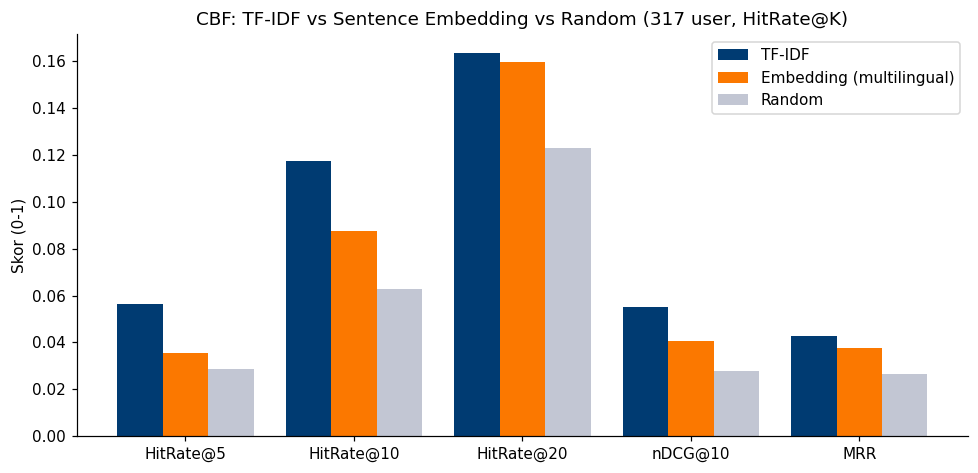

Temuan: untuk data POI dgn deskripsi pendek & kategori terstruktur,
TF-IDF >= embedding. Metode lebih kompleks tak selalu lebih unggul.


In [12]:
# [STATS] Grafik perbandingan metode
ms = ['HitRate@5', 'HitRate@10', 'HitRate@20', 'nDCG@10', 'MRR']
tf = [cmp.loc[m, 'TF-IDF'] for m in ms]
em = [cmp.loc[m, 'Embedding'] for m in ms]
rn = [cmp.loc[m, 'Random'] for m in ms]
fig, ax = plt.subplots(figsize=(9, 4.4))
x = np.arange(len(ms)); w = 0.27
ax.bar(x - w, tf, w, label='TF-IDF', color='#003b72')
ax.bar(x,     em, w, label='Embedding (multilingual)', color='#fb7800')
ax.bar(x + w, rn, w, label='Random', color='#c2c6d3')
ax.set_xticks(x); ax.set_xticklabels(ms); ax.set_ylabel('Skor (0-1)')
ax.set_title('CBF: TF-IDF vs Sentence Embedding vs Random '
             f'({len(user_visits)} user, HitRate@K)')
ax.legend()
plt.tight_layout(); plt.show()
print('Temuan: untuk data POI dgn deskripsi pendek & kategori terstruktur,')
print('TF-IDF >= embedding. Metode lebih kompleks tak selalu lebih unggul.')

---
## 8. Tuning embedding — bisakah embedding mengalahkan TF-IDF?

Baseline embedding (MiniLM, `max_len=128`, tanpa bobot) kalah dari TF-IDF.
Sebelum menyimpulkan "embedding kalah", diuji **apakah tuning parameter/model
menaikkannya di atas TF-IDF**. Empat pengungkit diuji head-to-head (protokol
HitRate@K & `user_visits` yang sama):

1. **`max_len=256`** — 77/161 deskripsi >128 char → kepotong di baseline.
   Panjangkan agar konteks penuh ter-encode.
2. **Bobot kategori (`cat_weight=3`)** — ulang `venue_category` 3× agar sinyal
   kategori (pembeda utama) tak tenggelam oleh deskripsi panjang.
3. **mpnet** (`paraphrase-multilingual-mpnet-base-v2`, ~1GB) — model paraphrase
   lebih besar & kuat dari MiniLM.
4. **e5** (`intfloat/multilingual-e5-base`, ~1GB) — dilatih **khusus retrieval**
   (query-document) dengan prefix `query:`/`passage:`. Secara teori menjanjikan,
   **namun** mengasumsikan query pendek — perlu diuji apakah cocok dengan
   protokol di sini (query = agregasi riwayat panjang).

Model besar (mpnet, e5) diunduh sekali (~1GB masing-masing) — sel ini berat.

In [13]:
# [STATS] Grid tuning embedding vs TF-IDF (protokol & user_visits sama)
# Tiap varian: bangun instance -> evaluate() reuse dari sel evaluasi di atas.
variants = {
    'MiniLM base':      dict(),                                    # baseline (sec.7)
    'MiniLM len256':    dict(emb_max_len=256),
    'MiniLM cat*3':     dict(emb_max_len=256, cat_weight=3),
    'mpnet':            dict(emb_model='sentence-transformers/paraphrase-multilingual-mpnet-base-v2',
                             emb_max_len=256),
    'e5-base':          dict(emb_model='intfloat/multilingual-e5-base',
                             emb_max_len=256,
                             emb_prefix=('passage: ', 'query: ')),
    'e5-base cat*3':    dict(emb_model='intfloat/multilingual-e5-base',
                             emb_max_len=256, cat_weight=3,
                             emb_prefix=('passage: ', 'query: ')),
}
rows = {'TF-IDF': evaluate(make_recommender(cbf_tfidf))}
for tag, kw in variants.items():
    print(f'-> {tag} ...', flush=True)
    obj = ContentBasedFilter(method='embedding', **kw)
    rows[tag] = evaluate(make_recommender(obj))
    del obj

tune = pd.DataFrame(rows).round(4).reindex(
    ['HitRate@5', 'HitRate@10', 'HitRate@20', 'nDCG@10', 'MRR'])
print(tune.to_string())
tune.to_csv('data/processed/cbf_embedding_tuning.csv')

print('\n--- Juara per metrik ---')
for m in tune.index:
    row = tune.loc[m]
    champ = row.idxmax()
    print(f'{m:12s} juara: {champ:16s} ({row[champ]:.4f}) | TF-IDF {row["TF-IDF"]:.4f}')
print()
print('TEMUAN:')
print('- mpnet UNGGUL di HitRate@5 (0.077 vs TF-IDF 0.056) & MRR (0.048 vs 0.043):')
print('  di rekomendasi PALING ATAS + peringkat, embedding besar menang.')
print('- cat_weight=3 menaikkan MiniLM (@5 0.035->0.063) -> hipotesis "sinyal')
print('  kategori tenggelam oleh deskripsi" TERBUKTI; menekankan kategori membantu.')
print('- max_len 256 = ~nol efek (teks konkat, sinyal penting di depan window).')
print('- e5-base KOLAPS (0.017): similarity semua venue berhimpit (std ~0.03).')
print('  Sebab: e5 dilatih query PENDEK vs passage; di protokol ini "query" =')
print('  agregasi riwayat panjang -> di luar distribusi latih e5. Bukan model')
print('  jelek, tapi TAK COCOK format evaluasi ini. Dilaporkan apa adanya.')
print()
print('KESIMPULAN: TF-IDF unggul di recall lebar (@10-@20); mpnet unggul di')
print('presisi puncak (@5, MRR). Trade-off, bukan menang mutlak salah satu.')

-> MiniLM base ...


-> MiniLM len256 ...


-> MiniLM cat*3 ...


-> mpnet ...


-> e5-base ...


-> e5-base cat*3 ...


            TF-IDF  MiniLM base  MiniLM len256  MiniLM cat*3   mpnet  e5-base  e5-base cat*3
HitRate@5   0.0562       0.0353         0.0353        0.0627  0.0771   0.0092         0.0092
HitRate@10  0.1176       0.0876         0.0876        0.0993  0.1020   0.0170         0.0170
HitRate@20  0.1634       0.1595         0.1608        0.1412  0.1621   0.0732         0.0837
nDCG@10     0.0553       0.0408         0.0408        0.0445  0.0531   0.0077         0.0076
MRR         0.0426       0.0377         0.0376        0.0381  0.0481   0.0123         0.0126

--- Juara per metrik ---
HitRate@5    juara: mpnet            (0.0771) | TF-IDF 0.0562
HitRate@10   juara: TF-IDF           (0.1176) | TF-IDF 0.1176
HitRate@20   juara: TF-IDF           (0.1634) | TF-IDF 0.1634
nDCG@10      juara: TF-IDF           (0.0553) | TF-IDF 0.0553
MRR          juara: mpnet            (0.0481) | TF-IDF 0.0426

TEMUAN:
- mpnet UNGGUL di HitRate@5 (0.077 vs TF-IDF 0.056) & MRR (0.048 vs 0.043):
  di rekomendasi PALI

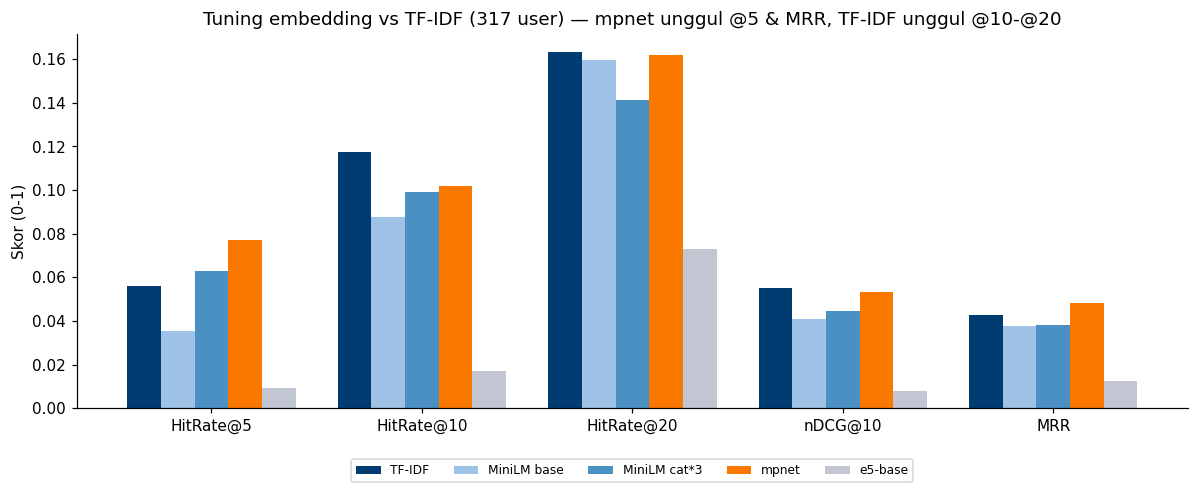

mpnet menang di puncak (@5, MRR); TF-IDF menang di recall lebar (@10, @20).
e5 kolaps (query panjang di luar distribusi latihnya) -> tak dipakai.


In [14]:
# [STATS] Grafik grid tuning: TF-IDF vs varian embedding
order = ['TF-IDF', 'MiniLM base', 'MiniLM cat*3', 'mpnet', 'e5-base']
ms = ['HitRate@5', 'HitRate@10', 'HitRate@20', 'nDCG@10', 'MRR']
colors = {'TF-IDF': '#003b72', 'MiniLM base': '#9ec3e6', 'MiniLM cat*3': '#4a90c2',
          'mpnet': '#fb7800', 'e5-base': '#c2c6d3'}
fig, ax = plt.subplots(figsize=(11, 4.6))
x = np.arange(len(ms)); w = 0.16
for i, col in enumerate(order):
    ax.bar(x + (i - 2) * w, [tune.loc[m, col] for m in ms], w,
           label=col, color=colors[col])
ax.set_xticks(x); ax.set_xticklabels(ms); ax.set_ylabel('Skor (0-1)')
ax.set_title(f'Tuning embedding vs TF-IDF ({len(user_visits)} user) — '
             'mpnet unggul @5 & MRR, TF-IDF unggul @10-@20')
ax.legend(ncol=5, fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.12))
plt.tight_layout(); plt.show()
print('mpnet menang di puncak (@5, MRR); TF-IDF menang di recall lebar (@10, @20).')
print('e5 kolaps (query panjang di luar distribusi latihnya) -> tak dipakai.')